Econml with lag features and both temp and rh as variable


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from econml.dml import CausalForestDML

In [17]:
df = pd.read_csv('/Users/ameypatil/Desktop/Tata Power/data/final.csv')

In [18]:
# Drop unwanted columns
df = df.drop(columns=['_id_x', '_id_y'])

# Convert datetime
df['datetime'] = pd.to_datetime(df['datetime'])
df = df.sort_values('datetime')
df.set_index('datetime', inplace=True)

# Feature engineering
df['hour'] = df.index.hour
df['dayofweek'] = df.index.dayofweek

# Lag features
df['lag_24'] = df['wdLoad'].shift(24)
df['lag_168'] = df['wdLoad'].shift(168)

# Drop NaN rows
df = df.dropna()

In [19]:
# Outcome
Y = df['wdLoad'].values

# ✅ Multiple Treatments
T = df[['temp','rh']].values

# ✅ Controls (IMPORTANT: exclude temp & rh)
X = df[['hour','dayofweek','lag_24','lag_168']].values

In [20]:
print(T.shape)

(288729, 2)


In [21]:
model = CausalForestDML(
    n_estimators=100,
    min_samples_leaf=10,
    random_state=42
)

model.fit(Y, T, X=X)

: 

In [ ]:

effects = model.const_marginal_effect(X)
print("Shape of effects:", effects.shape)

Shape of effects: (288729, 2)


In [ ]:
ate_temp = np.mean(effects[:, 0])
ate_rh = np.mean(effects[:, 1])

print("ATE (Temperature):", ate_temp)
print("ATE (Humidity):", ate_rh)

ATE (Temperature): 0.8496768484222237
ATE (Humidity): 0.002981653712506702


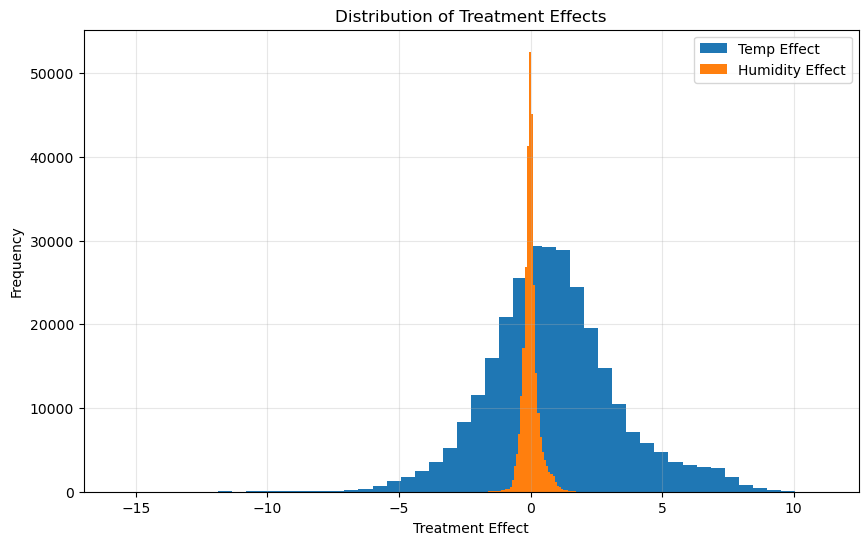

In [ ]:
plt.figure(figsize=(10,6))

plt.hist(effects[:,0], bins=50, label='Temp Effect')
plt.hist(effects[:,1], bins=50, label='Humidity Effect')

plt.xlabel("Treatment Effect")
plt.ylabel("Frequency")
plt.title("Distribution of Treatment Effects")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [ ]:
df_effect = pd.DataFrame(X, columns=['hour','dayofweek','lag_24','lag_168'])

df_effect['temp_effect'] = effects[:,0]
df_effect['rh_effect'] = effects[:,1]

print("\nEffect of Temperature by Hour:")
print(df_effect.groupby('hour')['temp_effect'].mean())

print("\nEffect of Humidity by Hour:")
print(df_effect.groupby('hour')['rh_effect'].mean())


Effect of Temperature by Hour:
hour
0.0    -0.710876
1.0    -0.927953
2.0    -0.616409
3.0    -0.247552
4.0    -0.081808
5.0     0.440211
6.0     1.553054
7.0     2.550083
8.0     3.185002
9.0     3.283617
10.0    2.344348
11.0    0.859979
12.0   -1.030942
13.0   -2.029185
14.0   -1.686694
15.0   -1.105587
16.0   -0.299348
17.0    1.275641
18.0    2.905550
19.0    3.532148
20.0    2.948508
21.0    2.255120
22.0    1.537044
23.0    0.459932
Name: temp_effect, dtype: float64

Effect of Humidity by Hour:
hour
0.0     0.032101
1.0     0.048114
2.0     0.052884
3.0     0.089902
4.0     0.077418
5.0     0.109008
6.0     0.209680
7.0     0.325412
8.0     0.314506
9.0     0.205062
10.0   -0.012136
11.0   -0.203267
12.0   -0.341596
13.0   -0.333549
14.0   -0.231005
15.0   -0.119682
16.0   -0.047127
17.0   -0.004000
18.0   -0.006767
19.0   -0.036845
20.0   -0.045055
21.0   -0.026801
22.0    0.001281
23.0    0.014330
Name: rh_effect, dtype: float64


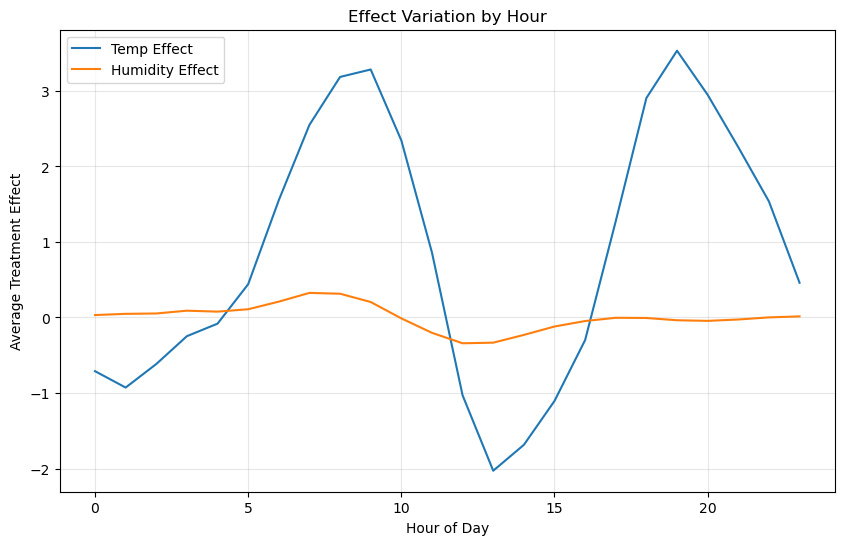

In [ ]:
temp_by_hour = df_effect.groupby('hour')['temp_effect'].mean()
rh_by_hour = df_effect.groupby('hour')['rh_effect'].mean()

plt.figure(figsize=(10,6))

plt.plot(temp_by_hour.index, temp_by_hour.values, label='Temp Effect')
plt.plot(rh_by_hour.index, rh_by_hour.values, label='Humidity Effect')

plt.xlabel("Hour of Day")
plt.ylabel("Average Treatment Effect")
plt.title("Effect Variation by Hour")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [ ]:
print("\n")
print(temp_by_hour)
print("\n Humidity Effect by Hour:")
print("\n")
print(rh_by_hour)



hour
0.0    -0.710876
1.0    -0.927953
2.0    -0.616409
3.0    -0.247552
4.0    -0.081808
5.0     0.440211
6.0     1.553054
7.0     2.550083
8.0     3.185002
9.0     3.283617
10.0    2.344348
11.0    0.859979
12.0   -1.030942
13.0   -2.029185
14.0   -1.686694
15.0   -1.105587
16.0   -0.299348
17.0    1.275641
18.0    2.905550
19.0    3.532148
20.0    2.948508
21.0    2.255120
22.0    1.537044
23.0    0.459932
Name: temp_effect, dtype: float64

 Humidity Effect by Hour:


hour
0.0     0.032101
1.0     0.048114
2.0     0.052884
3.0     0.089902
4.0     0.077418
5.0     0.109008
6.0     0.209680
7.0     0.325412
8.0     0.314506
9.0     0.205062
10.0   -0.012136
11.0   -0.203267
12.0   -0.341596
13.0   -0.333549
14.0   -0.231005
15.0   -0.119682
16.0   -0.047127
17.0   -0.004000
18.0   -0.006767
19.0   -0.036845
20.0   -0.045055
21.0   -0.026801
22.0    0.001281
23.0    0.014330
Name: rh_effect, dtype: float64
